In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display


# ==========================================
# 2. Visualization Function
# ==========================================
def visualize_cross_aggregated_results(csv_path, models_filter):
    if not os.path.exists(csv_path):
        print(f"Error: The file '{csv_path}' does not exist in the current directory.")
        return

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Melt the dataframe from wide to long format
    df_long = pd.melt(
        df, 
        id_vars=['Parameter', 'True_Value'], 
        var_name='Metric_Model', 
        value_name='Value'
    )

    # Split 'Metric_Model' into 'Metric' and 'Model'
    # n=1 ensures we only split on the first underscore (e.g., "RB" and "model_shift_mean")
    df_long[['Metric', 'Model']] = df_long['Metric_Model'].str.split('_', n=1, expand=True)

    # Drop rows with NaN values (if some parameters are missing in certain models)
    df_long = df_long.dropna(subset=['Value'])

    # --- NEW: Filter by specified models ---
    if models_filter:
        df_long = df_long[df_long['Model'].isin(models_filter)]
        if df_long.empty:
            print(f"Error: None of the models in {models_filter} were found in the CSV.")
            print("Available models in the CSV are:", df.columns.str.split('_', n=1).str[1].dropna().unique().tolist())
            return
        else:
            print(f"Filtering plots to show: {', '.join(models_filter)}")

    # Set the visual theme for the plots
    sns.set_theme(style="whitegrid")
    
    metrics_to_plot = ['RB', 'MSE', 'CP']
    scenario_name = os.path.basename(csv_path).replace('.csv', '')
    
    for metric in metrics_to_plot:
        subset = df_long[df_long['Metric'] == metric]
        
        if subset.empty:
            continue
            
        plt.figure(figsize=(14, 7))
        
        # Create a strip plot (dot plot)
        ax = sns.stripplot(
            data=subset, 
            x='Parameter', 
            y='Value', 
            hue='Model', 
            dodge=True, 
            marker='o', 
            alpha=0.8,
            size=7
        )
        
        plt.title(f'{metric} Comparison Across Models ({scenario_name})', fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.ylabel(metric, fontsize=12, fontweight='bold')
        plt.xlabel('Parameter', fontsize=12, fontweight='bold')
        
        # Place the legend outside the plot area
        plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
        
        # Add helpful reference lines
        if metric == 'CP':
            plt.axhline(y=95.0, color='red', linestyle='--', alpha=0.6, zorder=0)
            plt.text(len(subset['Parameter'].unique())-0.5, 95.5, '95% Nominal', color='red', ha='right')
        elif metric == 'RB':
            plt.axhline(y=0.0, color='red', linestyle='--', alpha=0.6, zorder=0)
            plt.text(len(subset['Parameter'].unique())-0.5, 0.02, 'Zero Bias', color='red', ha='right')
            
        plt.tight_layout()
        
        # Save the figure to disk
        out_filename = f'Plot_{metric}_{scenario_name}.png'
        # plt.savefig(out_filename, dpi=300, bbox_inches='tight')
        
        # Display the plot inline in the Jupyter Notebook
        plt.show()
        print(f"Saved plot: {out_filename}\n")


In [20]:
import pandas as pd
from IPython.display import display
import numpy as np

def display_metric_table(df, metric, apply_color=False):
    """
    Filters the dataframe to show only the base columns and the selected metric for all models,
    sorted by a custom parameter order matching the exact strings in the dataframe, 
    and highlights the best performing model in bold.
    
    Parameters:
    - df: The cross-aggregated dataframe.
    - metric: The prefix to search for (e.g., 'RB', 'MSE', 'CP').
    - apply_color: If True, attempts to apply a background gradient and bold text. 
                   If False, shows plain text.
    """
    # Custom order mapped from the original image to the specific dataframe strings
    desired_order = [
        'rho', 
        'theta1', 'theta2', 
        'theta5[1]', 'theta5[2]', 'theta5[3]', 
        'theta7[1]', 'theta7[2]', 'theta7[3]', 
        'lambda[1]', 'lambda[2]', 'lambda[3]', 
        'lambda[4]', 'lambda[5]', 'lambda[6]', 'lambda[7]', 
        'beta[2,1]', 'beta[2,2]', 
        'beta[5,1]', 'beta[5,2]', 
        'sigma_bk[1]', 'sigma_bk[3]', 'sigma_bk[4]', 'sigma_bk[7]', 
        'Gamma[1,1]', 'Gamma[1,2]', 'Gamma[2,1]', 'Gamma[2,2]'
    ]

    # 1. Identify the columns to keep
    base_cols = ['Parameter', 'True_Value']
    metric_cols = [col for col in df.columns if col.startswith(f"{metric}_")]
    
    if not metric_cols:
        print(f"No columns found for metric: {metric}")
        return
        
    cols_to_display = base_cols + metric_cols
    df_metric = df[cols_to_display].copy()
    
    # 2. Sort the dataframe by the custom order
    # Any parameter not in 'desired_order' gets len(desired_order) to push it to the end
    df_metric['sort_key'] = df_metric['Parameter'].apply(
        lambda x: desired_order.index(x.strip()) if x.strip() in desired_order else len(desired_order)
    )
    df_metric = df_metric.sort_values(by=['sort_key', 'Parameter']).drop('sort_key', axis=1).reset_index(drop=True)
    
    # 3. Define the bolding logic for the "best" value
    def highlight_best(row):
        styles = pd.Series([''] * len(row), index=row.index)
        
        # Determine the "best" column based on the metric type
        if metric in ['MSE', 'Rhat']:
            best_col = row.idxmin()
        elif metric == 'ESS':
            best_col = row.idxmax()
        elif metric == 'RB':
            best_col = row.abs().idxmin() # Closest to 0
        elif metric == 'CP':
            best_col = (row - 95).abs().idxmin() # Closest to 95%
        else:
            best_col = row.idxmax() # Default fallback
            
        if pd.notna(best_col):
            styles[best_col] = 'font-weight: bold'
            
        return styles

    print(f"\n--- {metric} Comparison Table ---")
    
    # 4. Apply Styling or Display Raw
    if apply_color:
        try:
            styled_df = (df_metric.style
                .background_gradient(subset=metric_cols, cmap='coolwarm', axis=1)
                .apply(highlight_best, subset=metric_cols, axis=1)
                .format({col: "{:.3f}" for col in metric_cols}))
            
            display(styled_df)
        except AttributeError:
            print("[Note] Jinja2 is not installed. Falling back to unstyled table.")
            display(df_metric)
    else:
        display(df_metric)

In [51]:
# Load your dataframe (if not already loaded in memory)
df = pd.read_csv("../corrected_results/FINAL_COMPARISON_S2_corrected.csv")
# df["Parameter"]

In [52]:
# ==========================================
# Try it out:
# ==========================================

# Display Rhat
display_metric_table(df, 'Rhat')




--- Rhat Comparison Table ---


,Parameter,True_Value,Rhat_model_shift_mean_paper,Rhat_model_shift_mean_cov,Rhat_model_fix_mean,Rhat_model_fix_mean_lap,Rhat_model_shift_mean_cov_lap
0,rho,0.60,1.023,1.027,1.036,1.019,1.017
1,theta1,2.30,1.002,1.002,1.002,1.002,1.002
2,theta2,2.60,1.012,1.010,1.010,1.014,1.012
3,theta5[1],-7.50,1.004,1.004,1.003,1.003,1.003
4,theta5[2],-2.50,1.003,1.002,1.002,1.002,1.003
5,theta5[3],2.60,1.003,1.002,1.002,1.002,1.005
6,theta7[1],-4.30,1.002,1.002,1.001,1.002,1.002
7,theta7[2],-1.00,1.002,1.002,1.001,1.001,1.001
8,theta7[3],1.40,1.002,1.003,1.002,1.002,1.001
9,lambda[1],1.20,1.006,1.010,1.003,1.004,1.006


In [53]:
# Display Effective Sample Size
display_metric_table(df, 'ESS')




--- ESS Comparison Table ---


,Parameter,True_Value,ESS_model_shift_mean_paper,ESS_model_shift_mean_cov,ESS_model_fix_mean,ESS_model_fix_mean_lap,ESS_model_shift_mean_cov_lap
0,rho,0.60,921.1,919.5,928.2,988.3,979.8
1,theta1,2.30,4638.1,4641.7,4794.7,4733.5,4735.7
2,theta2,2.60,1846.4,1948.3,1871.3,1840.9,1883.8
3,theta5[1],-7.50,3239.7,3276.0,3402.9,3469.0,3414.6
4,theta5[2],-2.50,4773.2,5238.0,5574.6,5801.7,5464.5
5,theta5[3],2.60,5031.9,5470.7,5879.8,5960.2,5724.9
6,theta7[1],-4.30,6152.7,6659.2,7028.7,6992.2,6767.4
7,theta7[2],-1.00,5875.6,6701.8,7315.1,7506.6,6951.3
8,theta7[3],1.40,5795.3,6540.3,7136.9,7295.1,6769.5
9,lambda[1],1.20,3871.0,3961.4,3978.1,4058.6,4127.7


In [54]:
# Display Coverage Probability
display_metric_table(df, 'CP')


--- CP Comparison Table ---


,Parameter,True_Value,CP_model_shift_mean_paper,CP_model_shift_mean_cov,CP_model_fix_mean,CP_model_fix_mean_lap,CP_model_shift_mean_cov_lap
0,rho,0.60,93.9,94.3,95.0,96.7,96.6
1,theta1,2.30,97.6,97.2,95.6,96.2,96.6
2,theta2,2.60,93.3,95.0,95.6,95.6,95.5
3,theta5[1],-7.50,93.9,93.6,94.3,94.5,93.2
4,theta5[2],-2.50,93.3,95.7,95.0,93.4,94.4
5,theta5[3],2.60,94.5,94.3,95.0,95.6,93.8
6,theta7[1],-4.30,95.2,95.7,94.3,94.0,96.6
7,theta7[2],-1.00,91.5,90.1,93.7,92.9,92.1
8,theta7[3],1.40,93.3,96.5,94.3,94.0,95.5
9,lambda[1],1.20,98.2,99.3,95.6,97.3,97.7


In [55]:
# Display Relative Bias
display_metric_table(df, 'RB')


--- RB Comparison Table ---


,Parameter,True_Value,RB_model_shift_mean_paper,RB_model_shift_mean_cov,RB_model_fix_mean,RB_model_fix_mean_lap,RB_model_shift_mean_cov_lap
0,rho,0.60,0.021,0.020,0.022,0.013,0.013
1,theta1,2.30,0.024,0.019,0.015,0.013,0.012
2,theta2,2.60,0.061,0.054,0.059,0.051,0.050
3,theta5[1],-7.50,-0.002,-0.004,-0.007,-0.005,-0.007
4,theta5[2],-2.50,0.007,-0.001,-0.004,0.007,-0.000
5,theta5[3],2.60,-0.017,-0.017,-0.019,-0.019,-0.016
6,theta7[1],-4.30,0.007,0.008,0.006,0.007,0.006
7,theta7[2],-1.00,0.009,0.012,0.002,0.007,0.009
8,theta7[3],1.40,-0.005,-0.003,0.005,0.000,-0.002
9,lambda[1],1.20,0.008,-0.001,0.002,0.017,0.011


In [56]:
# Display Mean Squared Error
display_metric_table(df, 'MSE')


--- MSE Comparison Table ---


,Parameter,True_Value,MSE_model_shift_mean_paper,MSE_model_shift_mean_cov,MSE_model_fix_mean,MSE_model_fix_mean_lap,MSE_model_shift_mean_cov_lap
0,rho,0.60,0.003,0.003,0.003,0.003,0.003
1,theta1,2.30,0.079,0.075,0.085,0.082,0.080
2,theta2,2.60,0.235,0.221,0.236,0.215,0.222
3,theta5[1],-7.50,0.359,0.343,0.329,0.343,0.359
4,theta5[2],-2.50,0.162,0.149,0.133,0.148,0.152
5,theta5[3],2.60,0.149,0.139,0.134,0.135,0.144
6,theta7[1],-4.30,0.035,0.035,0.034,0.034,0.033
7,theta7[2],-1.00,0.020,0.020,0.017,0.017,0.019
8,theta7[3],1.40,0.019,0.016,0.016,0.016,0.017
9,lambda[1],1.20,0.041,0.039,0.049,0.046,0.045


Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_paper, model_fix_mean


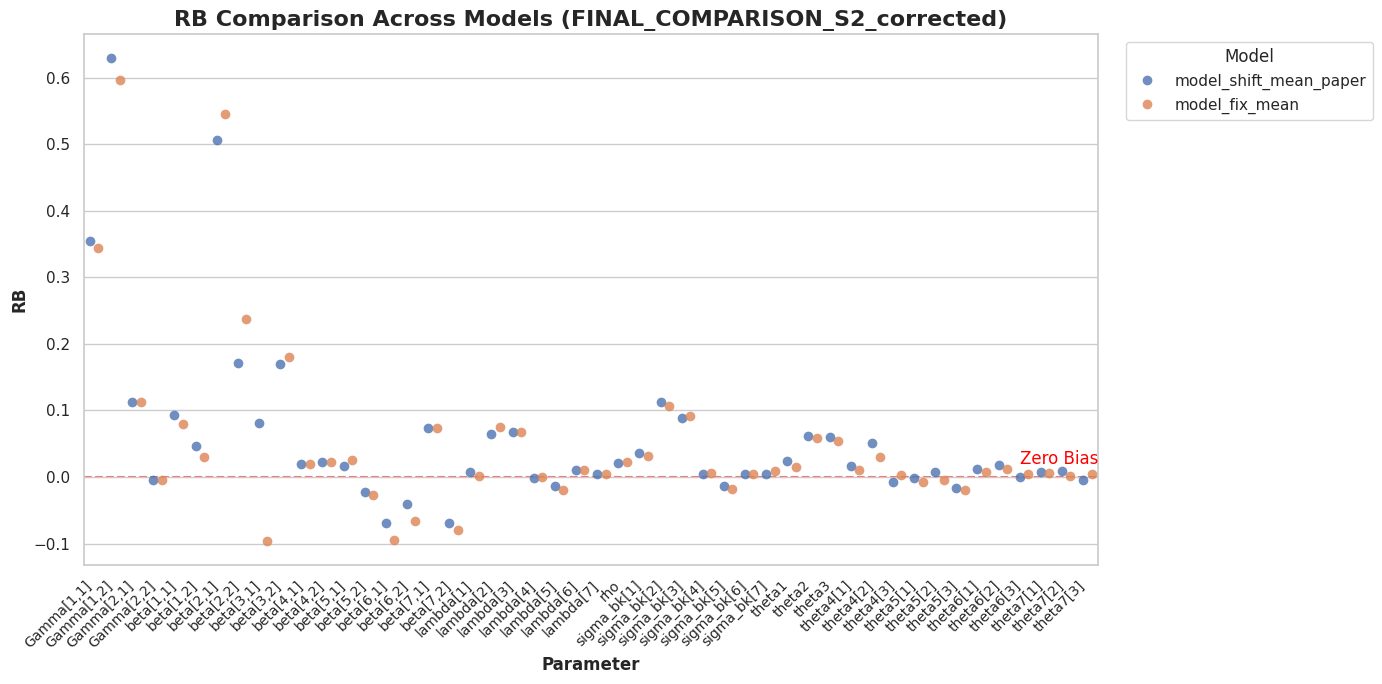

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



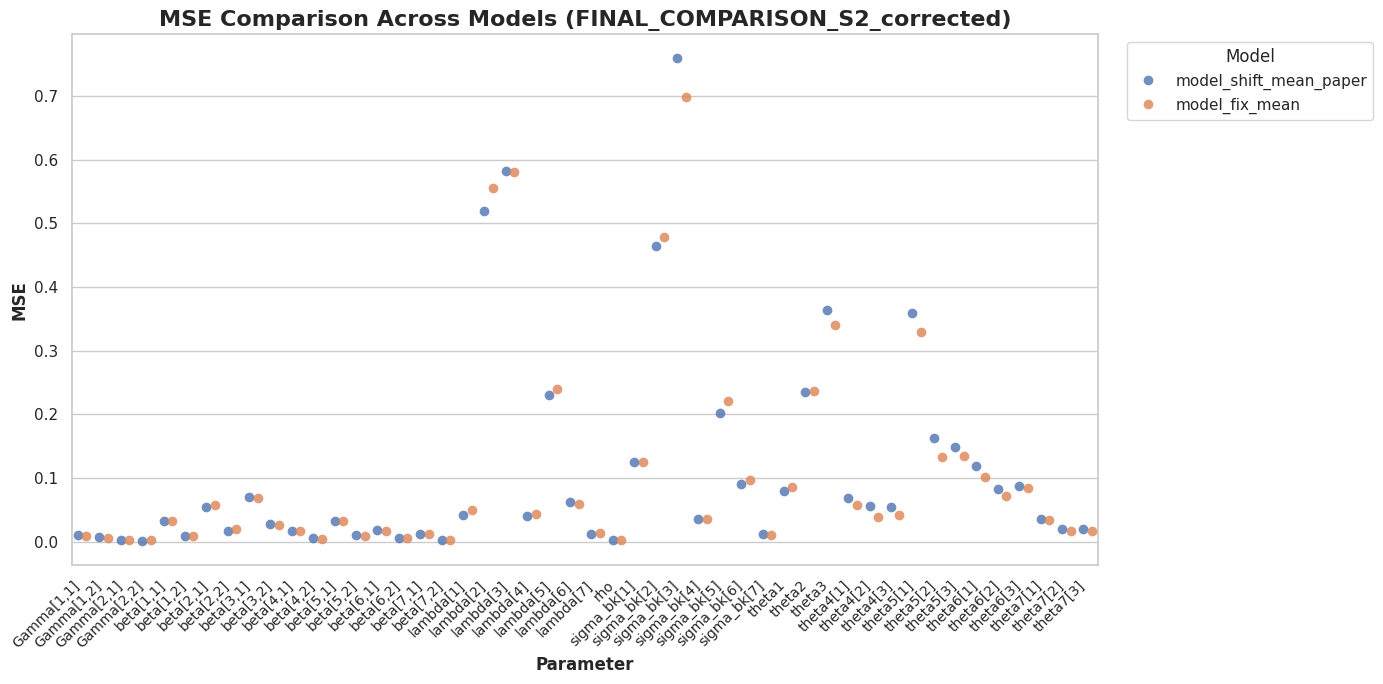

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



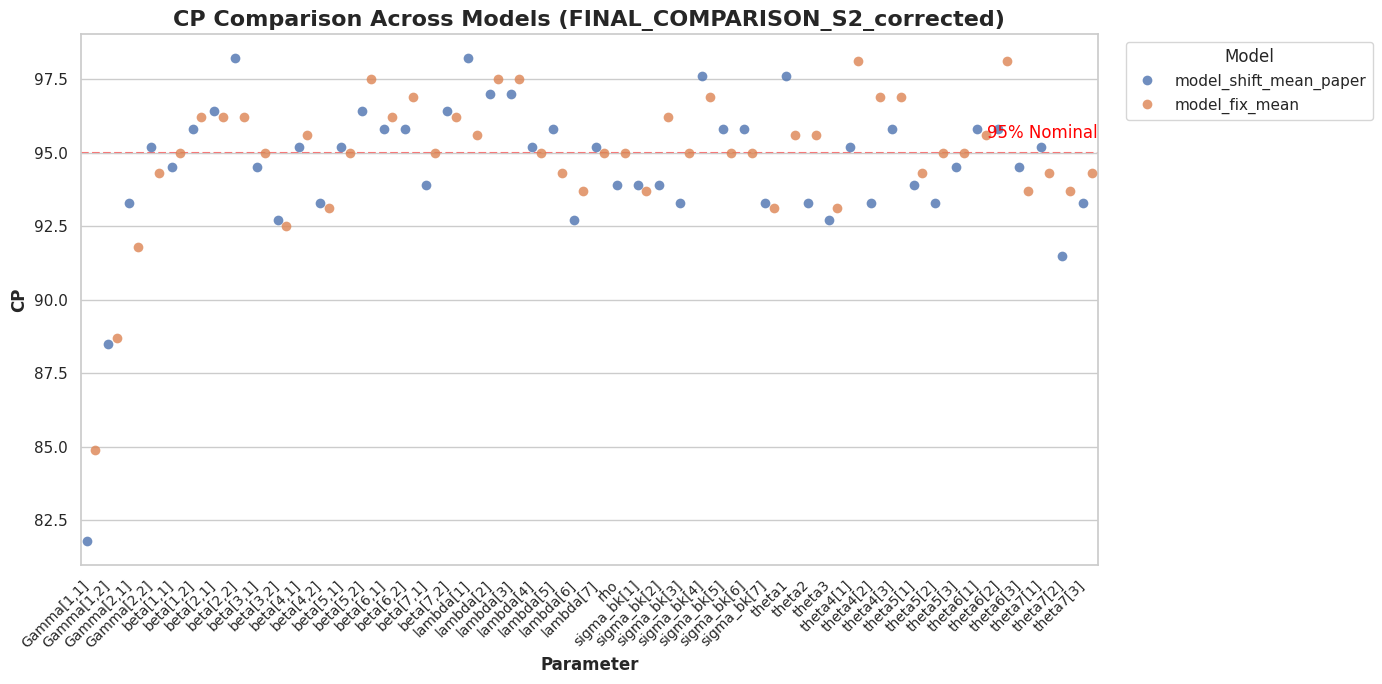

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [38]:

# ==========================================
# 1. Configuration
# ==========================================
# Change this to the name of the CSV you want to visualize
csv_path = "../corrected_results/FINAL_COMPARISON_S2_corrected.csv"

# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_paper",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_cov, model_fix_mean


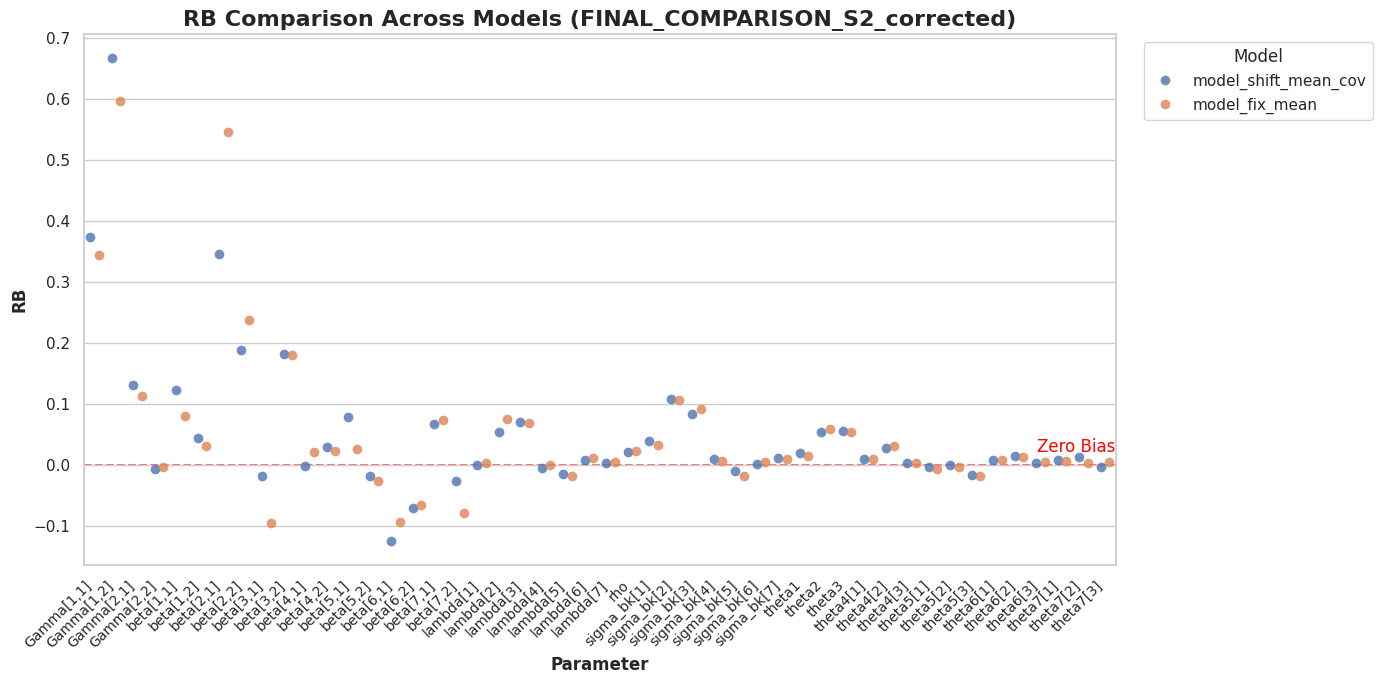

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



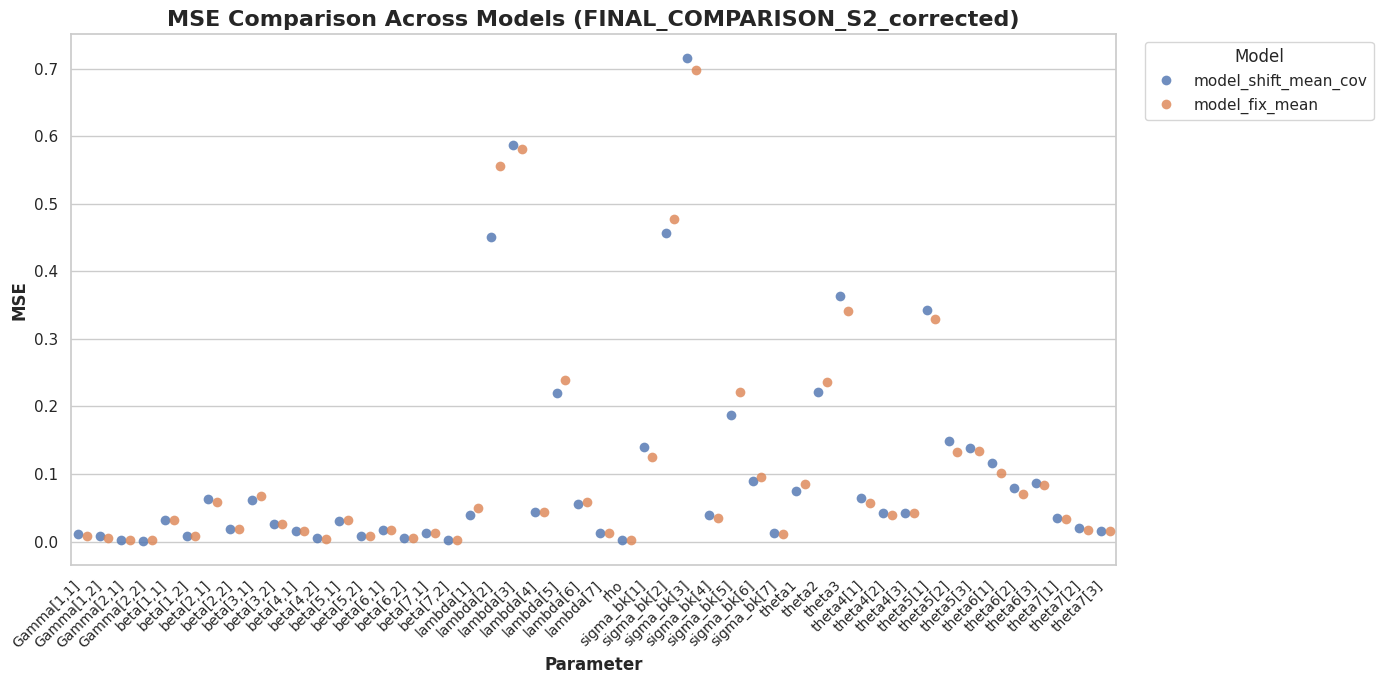

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



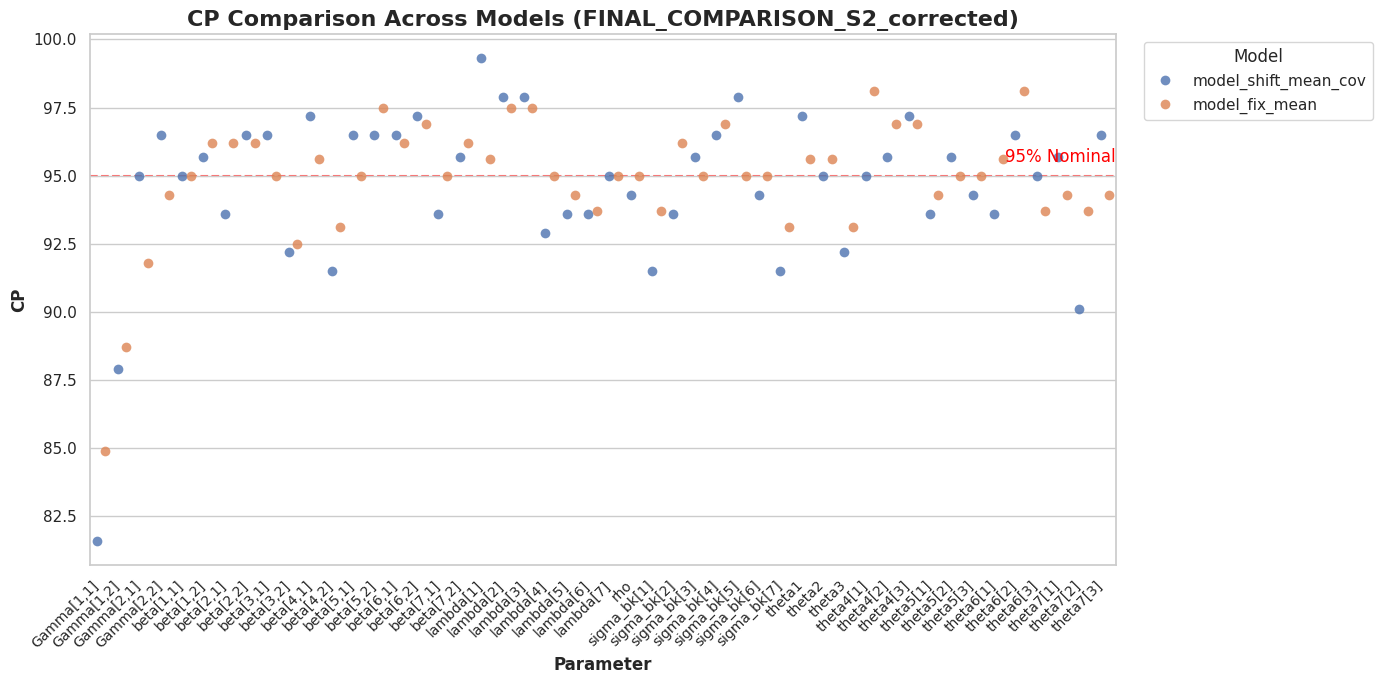

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [39]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_cov",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_fix_mean_lap, model_fix_mean


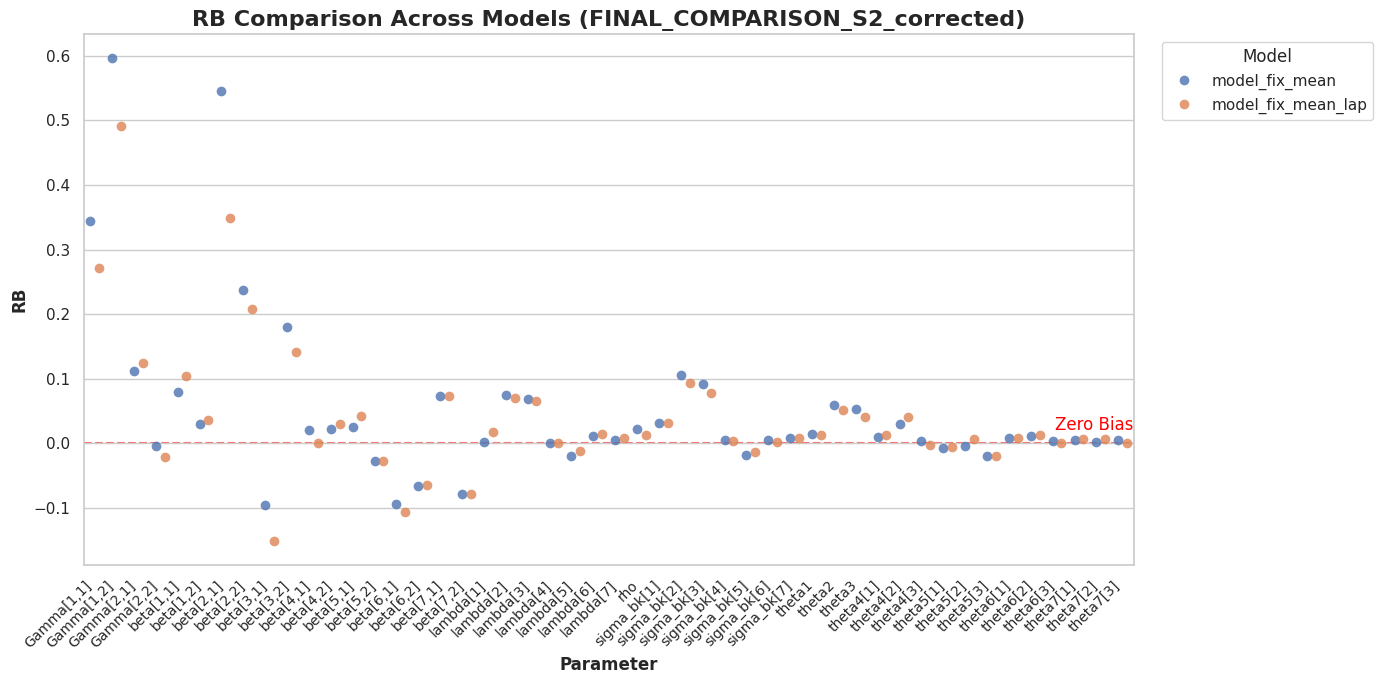

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



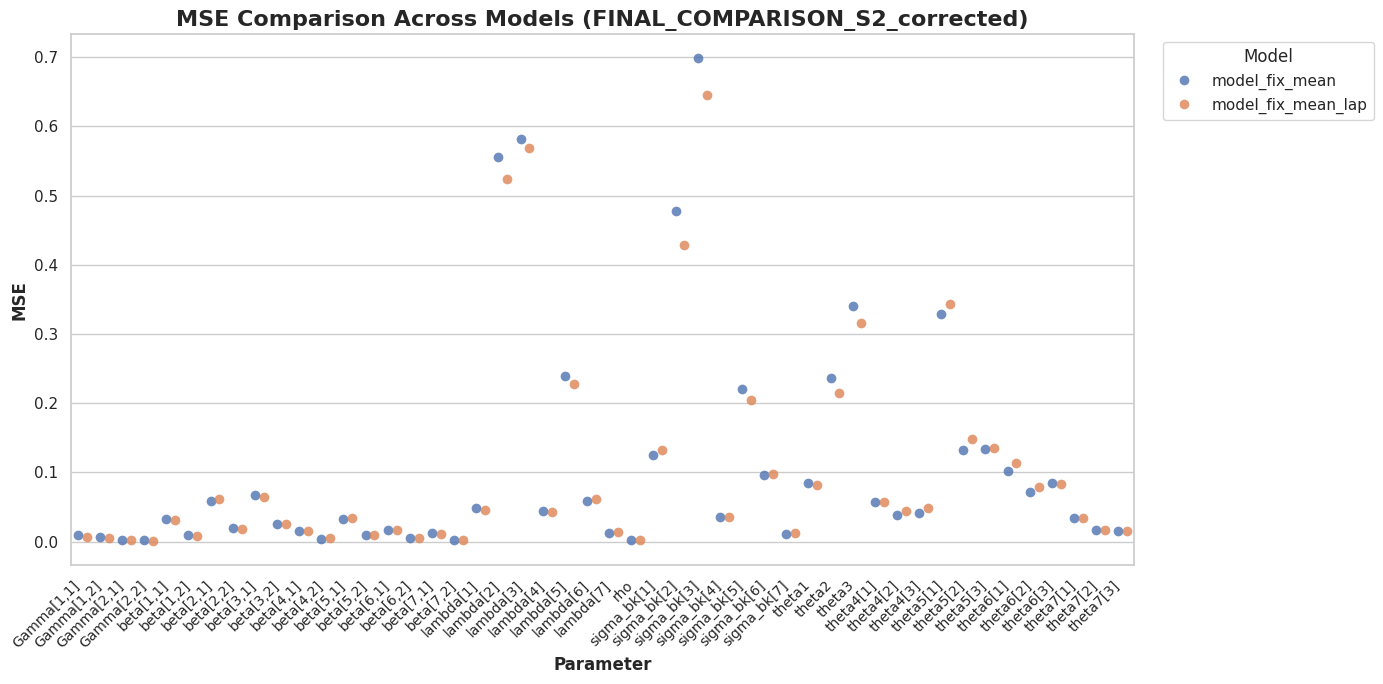

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



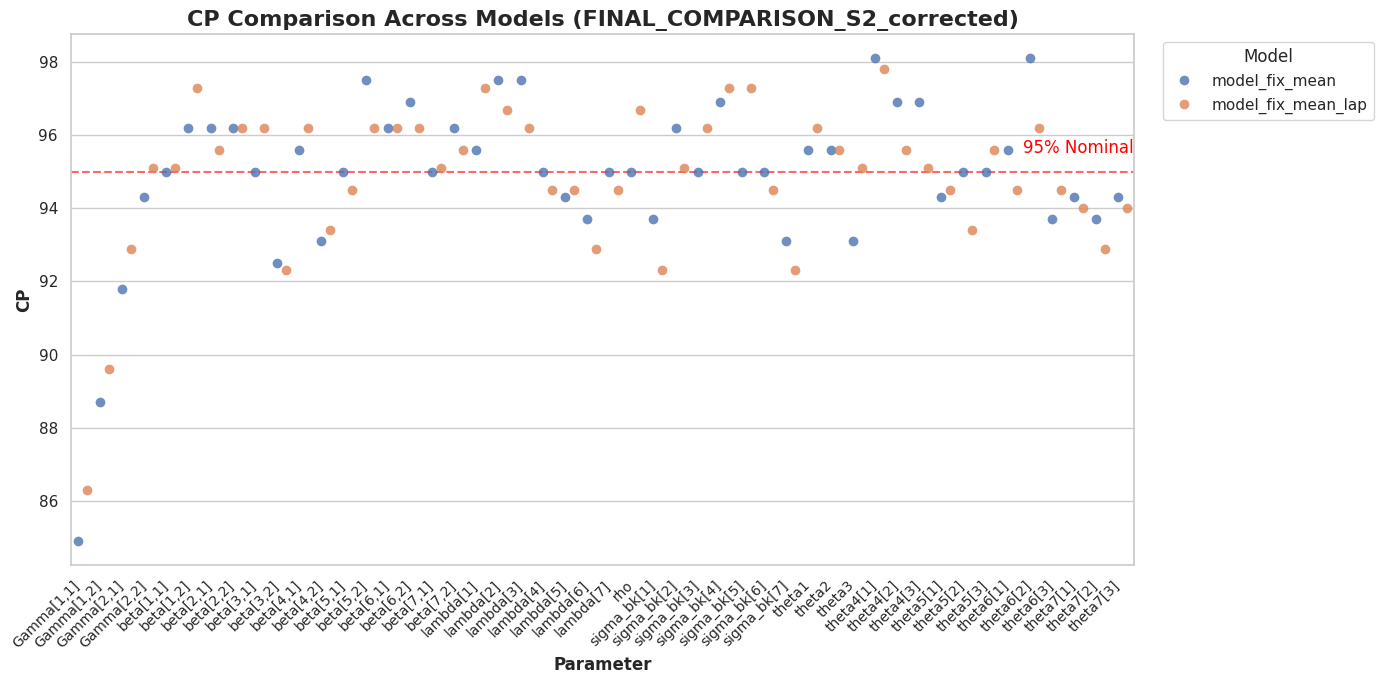

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [40]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_fix_mean_lap",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_cov_lap, model_shift_mean_cov


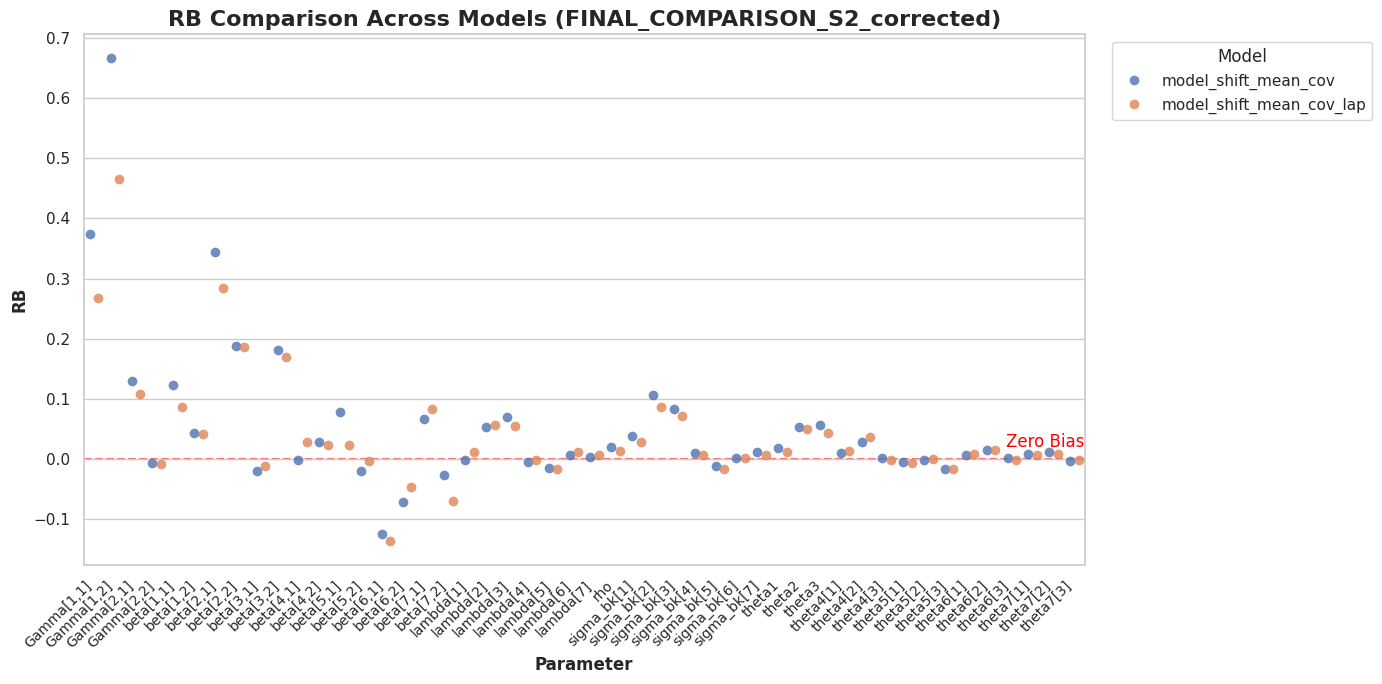

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



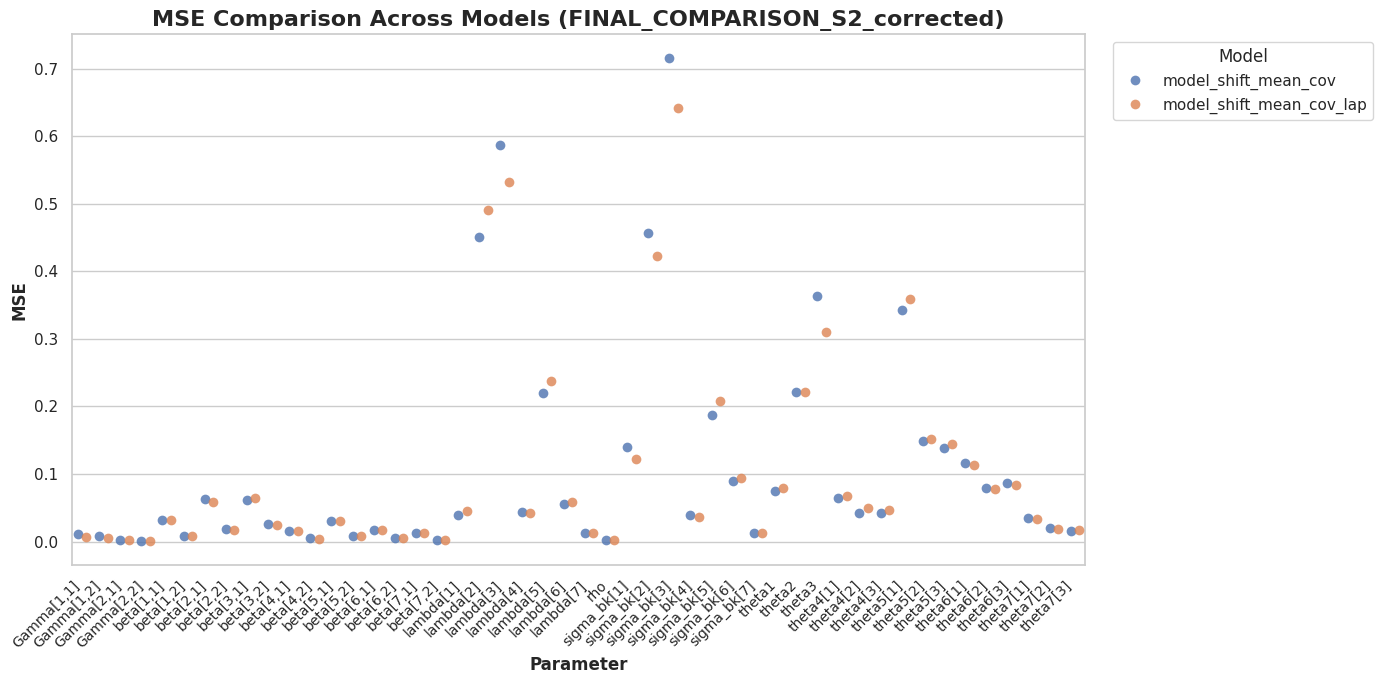

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



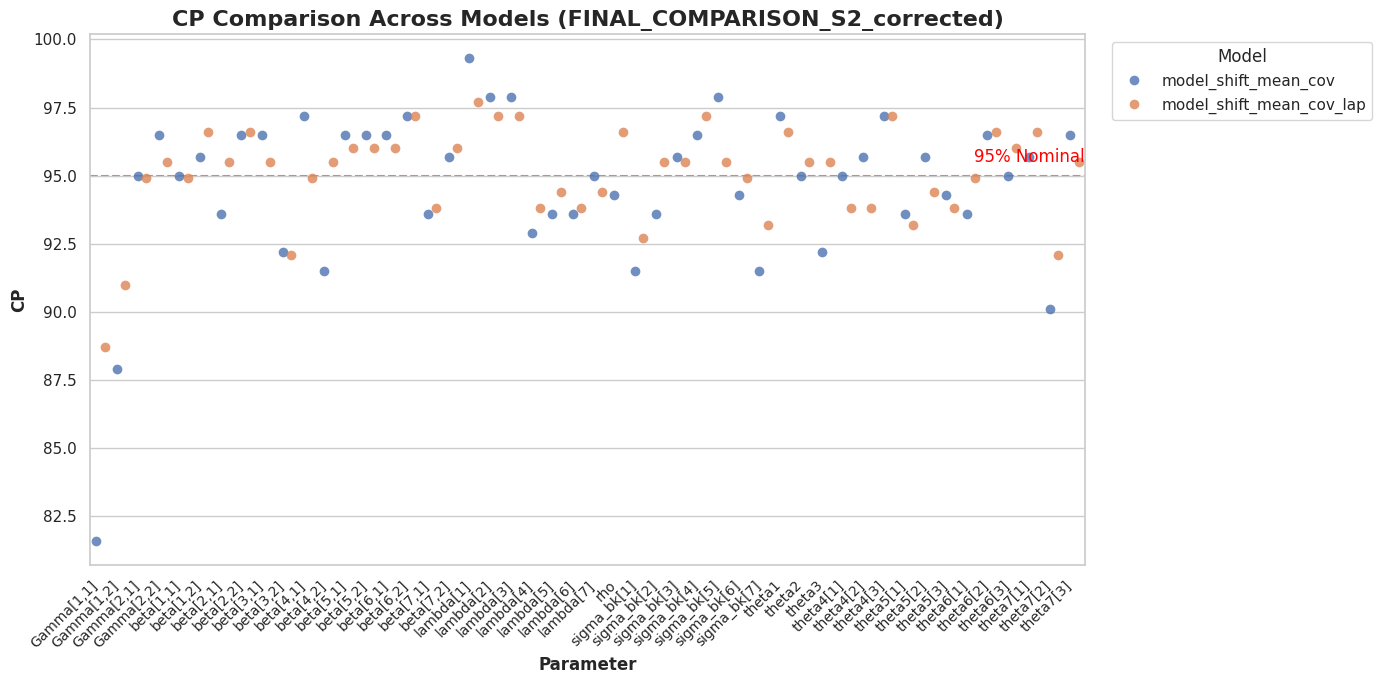

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [41]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_cov_lap",
    "model_shift_mean_cov"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

In [44]:
df = pd.read_csv("../corrected_results/results_S2_model_shift_mean_paper_run163.csv")
df

,Run_ID,Parameter,True_Value,Estimate,2.5%,97.5%,R_hat,ESS,Rbias,MSE,Coverage
0,163,theta1,2.30,2.647400,2.083090,3.298110,0.999791,4062.710,0.151043,0.120687,1
1,163,theta2,2.60,2.721430,1.915010,3.778100,1.001680,1748.340,0.046704,0.014745,1
2,163,theta3,2.90,3.481830,2.338180,5.060820,1.000990,1193.300,0.200631,0.338526,1
3,163,theta4[1],-4.00,-4.418830,-4.920650,-3.950590,1.000380,7997.920,0.104707,0.175419,1
4,163,theta4[2],-1.00,-1.199400,-1.599020,-0.817618,1.000390,7968.750,0.199400,0.039760,1
5,163,theta4[3],2.70,2.457120,2.048000,2.870610,1.000070,7640.460,-0.089956,0.058991,1
6,163,theta5[1],-7.50,-7.375260,-8.753430,-6.225740,1.000300,2924.460,-0.016632,0.015560,1
7,163,theta5[2],-2.50,-2.298510,-3.123540,-1.540620,1.000410,5625.980,-0.080596,0.040598,1
8,163,theta5[3],2.60,3.163180,2.363030,4.064450,0.999963,6016.060,0.216608,0.317172,1
9,163,theta6[1],-5.50,-5.674170,-6.412730,-4.983780,1.000530,7373.310,0.031667,0.030335,1
